In [1]:
# ====================================================================
# 3일차 실습
# AI4I 2020 데이터 ETL + SQLite 적재 + SQL 조회 + 품질관리 + 모니터링
# ====================================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from datetime import datetime
import sqlite3

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

In [2]:
# ---------------------------------------------------------
# 0. 환경 설정
# ---------------------------------------------------------
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:.3f}".format)

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.unicode_minus"] = False

sns.set_theme(style="whitegrid")

In [3]:
# ---------------------------------------------------------
# 1. 프로젝트 구조 준비
# ---------------------------------------------------------
base_dir = Path(".")
data_dir = base_dir / "data"
etl_dir = base_dir / "etl_project"
raw_dir = etl_dir / "raw"
staging_dir = etl_dir / "staging"
mart_dir = etl_dir / "mart"
log_dir = etl_dir / "logs"

raw_dir.mkdir(parents=True, exist_ok=True)
staging_dir.mkdir(parents=True, exist_ok=True)
mart_dir.mkdir(parents=True, exist_ok=True)
log_dir.mkdir(parents=True, exist_ok=True)

db_path = etl_dir / "ai4i_etl.db"

print("프로젝트 폴더 준비 완료")
print("raw_dir    :", raw_dir)
print("staging_dir:", staging_dir)
print("mart_dir   :", mart_dir)
print("log_dir    :", log_dir)
print("db_path    :", db_path)

프로젝트 폴더 준비 완료
raw_dir    : etl_project/raw
staging_dir: etl_project/staging
mart_dir   : etl_project/mart
log_dir    : etl_project/logs
db_path    : etl_project/ai4i_etl.db


In [4]:
# ---------------------------------------------------------
# 2. ETL 개요 설명
# ---------------------------------------------------------
print("\nETL 개요")
print("- Extract : 원천 데이터 읽기")
print("- Transform : 정제, 파생변수 생성, 품질 규칙 적용")
print("- Load : DB나 결과 테이블에 적재")

print("\n오늘의 목표")
print("1) AI4I 데이터를 ETL 흐름으로 처리")
print("2) SQLite에 raw / staging / mart 적재")
print("3) SQL로 업무용 조회")
print("4) 품질관리 결과와 실행 로그 남기기")
print("5) 모니터링용 파일 생성")


ETL 개요
- Extract : 원천 데이터 읽기
- Transform : 정제, 파생변수 생성, 품질 규칙 적용
- Load : DB나 결과 테이블에 적재

오늘의 목표
1) AI4I 데이터를 ETL 흐름으로 처리
2) SQLite에 raw / staging / mart 적재
3) SQL로 업무용 조회
4) 품질관리 결과와 실행 로그 남기기
5) 모니터링용 파일 생성


In [5]:
# ---------------------------------------------------------
# 3. Extract: 원천 데이터 읽기
# ---------------------------------------------------------
source_file = data_dir / "ai4i2020.csv"
df_raw = pd.read_csv(source_file)

df_raw.columns = [
    "udi",
    "product_id",
    "type",
    "air_temp_k",
    "process_temp_k",
    "rotational_speed_rpm",
    "torque_nm",
    "tool_wear_min",
    "machine_failure",
    "twf",
    "hdf",
    "pwf",
    "osf",
    "rnf"
]

print("\n원천 데이터 읽기 완료")
print(f"행 수: {df_raw.shape[0]:,}, 열 수: {df_raw.shape[1]:,}")
display(df_raw.head())

run_time = datetime.now().strftime("%Y%m%d_%H%M%S")
raw_copy_path = raw_dir / f"ai4i_raw_{run_time}.csv"
df_raw.to_csv(raw_copy_path, index=False, encoding="utf-8-sig")

print("\n원본(raw) 복사 저장 완료:", raw_copy_path)


원천 데이터 읽기 완료
행 수: 10,000, 열 수: 14


,udi,product_id,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf
0,1,M14860,M,298.100,308.600,1551,42.800,0,0,0,0,0,0,0
1,2,L47181,L,298.200,308.700,1408,46.300,3,0,0,0,0,0,0
2,3,L47182,L,298.100,308.500,1498,49.400,5,0,0,0,0,0,0
3,4,L47183,L,298.200,308.600,1433,39.500,7,0,0,0,0,0,0
4,5,L47184,L,298.200,308.700,1408,40.000,9,0,0,0,0,0,0



원본(raw) 복사 저장 완료: etl_project/raw/ai4i_raw_20260325_125947.csv


In [6]:
# ---------------------------------------------------------
# 4. 품질 점검 규칙 정의
# 적재 전에 최소한의 체크를 수행
# ---------------------------------------------------------
quality_rules = []

quality_rules.append({
    "rule_name": "row_count_gt_0",
    "description": "행 수가 0보다 커야 한다",
    "value": len(df_raw),
    "passed": len(df_raw) > 0
})

quality_rules.append({
    "rule_name": "null_count_total",
    "description": "전체 결측치 수 확인",
    "value": int(df_raw.isnull().sum().sum()),
    "passed": int(df_raw.isnull().sum().sum()) == 0
})

quality_rules.append({
    "rule_name": "duplicated_udi_count",
    "description": "udi 중복이 없어야 한다",
    "value": int(df_raw["udi"].duplicated().sum()),
    "passed": int(df_raw["udi"].duplicated().sum()) == 0
})

quality_rules.append({
    "rule_name": "valid_type_only",
    "description": "type은 L/M/H만 허용",
    "value": int((~df_raw["type"].isin(["L", "M", "H"])).sum()),
    "passed": int((~df_raw["type"].isin(["L", "M", "H"])).sum()) == 0
})

quality_rules.append({
    "rule_name": "machine_failure_binary",
    "description": "machine_failure는 0/1만 허용",
    "value": int((~df_raw["machine_failure"].isin([0, 1])).sum()),
    "passed": int((~df_raw["machine_failure"].isin([0, 1])).sum()) == 0
})

quality_rules.append({
    "rule_name": "tool_wear_non_negative",
    "description": "tool_wear_min은 음수가 아니어야 한다",
    "value": int((df_raw["tool_wear_min"] < 0).sum()),
    "passed": int((df_raw["tool_wear_min"] < 0).sum()) == 0
})

quality_df = pd.DataFrame(quality_rules)

print("\n품질 점검 결과")
display(quality_df)

print("\n품질 점검 해석")
print("- passed=True 이면 해당 규칙을 통과한 것입니다.")
print("- 실무에서는 적재 전에 이런 규칙을 자동 점검하는 경우가 많습니다.")
print("- 품질 점검은 데이터 분석의 부가 기능이 아니라 운영 안정성을 위한 핵심 기능입니다.")


품질 점검 결과


,rule_name,description,value,passed
0,row_count_gt_0,행 수가 0보다 커야 한다,10000,True
1,null_count_total,전체 결측치 수 확인,0,True
2,duplicated_udi_count,udi 중복이 없어야 한다,0,True
3,valid_type_only,type은 L/M/H만 허용,0,True
4,machine_failure_binary,machine_failure는 0/1만 허용,0,True
5,tool_wear_non_negative,tool_wear_min은 음수가 아니어야 한다,0,True



품질 점검 해석
- passed=True 이면 해당 규칙을 통과한 것입니다.
- 실무에서는 적재 전에 이런 규칙을 자동 점검하는 경우가 많습니다.
- 품질 점검은 데이터 분석의 부가 기능이 아니라 운영 안정성을 위한 핵심 기능입니다.


In [7]:
# ---------------------------------------------------------
# 5. Transform: 전처리 및 파생변수 생성
# ---------------------------------------------------------
df_staging = df_raw.copy()

# 5-1. product_id 앞 글자 추출
df_staging["product_code"] = df_staging["product_id"].str[0]

# 5-2. type과 product_code 일치 여부
df_staging["type_match"] = np.where(df_staging["type"] == df_staging["product_code"], 1, 0)

# 5-3. 온도 차이
df_staging["temp_diff"] = df_staging["process_temp_k"] - df_staging["air_temp_k"]

# 5-4. 회전수와 토크를 함께 보는 단순 지표
df_staging["power_proxy"] = df_staging["rotational_speed_rpm"] * df_staging["torque_nm"]

# 5-5. 공구 마모 구간화
df_staging["tool_wear_group"] = pd.cut(
    df_staging["tool_wear_min"],
    bins=[-1, 50, 150, 300],
    labels=["low", "mid", "high"]
)

# 5-6. 공구 마모 경고 기준
df_staging["tool_wear_alert"] = np.where(df_staging["tool_wear_min"] >= 200, 1, 0)

# 5-7. 세부 고장 유형 개수
failure_cols = ["twf", "hdf", "pwf", "osf", "rnf"]
df_staging["failure_type_count"] = df_staging[failure_cols].sum(axis=1)

# 5-8. 위험도 느낌의 단순 점수
df_staging["risk_score"] = (
    df_staging["temp_diff"] * 0.2 +
    df_staging["tool_wear_min"] * 0.4 +
    df_staging["torque_nm"] * 0.2 +
    df_staging["machine_failure"] * 50
).round(3)

print("\nstaging 데이터 상위 5행")
display(df_staging.head())

print("\nTransform 해석")
print("- staging은 raw를 그대로 두고, 분석/적재용으로 가공한 중간 단계입니다.")
print("- temp_diff, power_proxy, tool_wear_group은 업무 해석을 쉽게 해주는 파생변수입니다.")
print("- risk_score는 예시용 단순 지표로, 현업에서는 더 정교한 기준을 만들 수 있습니다.")


staging 데이터 상위 5행


,udi,product_id,type,air_temp_k,process_temp_k,rotational_speed_rpm,torque_nm,tool_wear_min,machine_failure,twf,hdf,pwf,osf,rnf,product_code,type_match,temp_diff,power_proxy,tool_wear_group,tool_wear_alert,failure_type_count,risk_score
0,1,M14860,M,298.100,308.600,1551,42.800,0,0,0,0,0,0,0,M,1,10.500,66382.800,low,0,0,10.660
1,2,L47181,L,298.200,308.700,1408,46.300,3,0,0,0,0,0,0,L,1,10.500,65190.400,low,0,0,12.560
2,3,L47182,L,298.100,308.500,1498,49.400,5,0,0,0,0,0,0,L,1,10.400,74001.200,low,0,0,13.960
3,4,L47183,L,298.200,308.600,1433,39.500,7,0,0,0,0,0,0,L,1,10.400,56603.500,low,0,0,12.780
4,5,L47184,L,298.200,308.700,1408,40.000,9,0,0,0,0,0,0,L,1,10.500,56320.000,low,0,0,13.700



Transform 해석
- staging은 raw를 그대로 두고, 분석/적재용으로 가공한 중간 단계입니다.
- temp_diff, power_proxy, tool_wear_group은 업무 해석을 쉽게 해주는 파생변수입니다.
- risk_score는 예시용 단순 지표로, 현업에서는 더 정교한 기준을 만들 수 있습니다.


In [8]:
# ---------------------------------------------------------
# 6. staging 품질 요약
# ---------------------------------------------------------
staging_summary = pd.DataFrame({
    "metric": [
        "row_count",
        "column_count",
        "type_match_rate",
        "failure_rate",
        "tool_wear_alert_rate",
        "avg_temp_diff",
        "avg_power_proxy",
        "avg_risk_score"
    ],
    "value": [
        len(df_staging),
        len(df_staging.columns),
        round(df_staging["type_match"].mean(), 4),
        round(df_staging["machine_failure"].mean(), 4),
        round(df_staging["tool_wear_alert"].mean(), 4),
        round(df_staging["temp_diff"].mean(), 4),
        round(df_staging["power_proxy"].mean(), 4),
        round(df_staging["risk_score"].mean(), 4)
    ]
})

print("\nstaging 요약")
display(staging_summary)


staging 요약


,metric,value
0,row_count,10000.000
1,column_count,22.000
2,type_match_rate,1.000
3,failure_rate,0.034
4,tool_wear_alert_rate,0.080
5,avg_temp_diff,10.001
6,avg_power_proxy,59967.147
7,avg_risk_score,54.873


In [9]:
# ---------------------------------------------------------
# 7. staging 파일 저장
# ---------------------------------------------------------
staging_file = staging_dir / f"ai4i_staging_{run_time}.csv"
df_staging.to_csv(staging_file, index=False, encoding="utf-8-sig")

print("\nstaging 저장 완료:", staging_file)


staging 저장 완료: etl_project/staging/ai4i_staging_20260325_125947.csv


In [10]:
# ---------------------------------------------------------
# 8. Load: SQLite 적재
# raw / staging / mart 테이블 구조 만들기
# ---------------------------------------------------------
conn = sqlite3.connect(db_path)

df_raw.to_sql("raw_ai4i", conn, if_exists="replace", index=False)
df_staging.to_sql("staging_ai4i", conn, if_exists="replace", index=False)

print("\nSQLite 적재 완료")
print("- raw_ai4i")
print("- staging_ai4i")


SQLite 적재 완료
- raw_ai4i
- staging_ai4i


In [11]:
# ---------------------------------------------------------
# 9. mart 테이블 생성용 요약 데이터
# 현업에서는 raw/staging보다 mart를 많이 조회함
# ---------------------------------------------------------
mart_type_summary = df_staging.groupby("type").agg(
    record_count=("udi", "count"),
    avg_air_temp=("air_temp_k", "mean"),
    avg_process_temp=("process_temp_k", "mean"),
    avg_rpm=("rotational_speed_rpm", "mean"),
    avg_torque=("torque_nm", "mean"),
    avg_tool_wear=("tool_wear_min", "mean"),
    avg_temp_diff=("temp_diff", "mean"),
    avg_power_proxy=("power_proxy", "mean"),
    failure_rate=("machine_failure", "mean"),
    alert_rate=("tool_wear_alert", "mean")
).round(3).reset_index()

mart_wear_summary = df_staging.groupby("tool_wear_group").agg(
    record_count=("udi", "count"),
    avg_tool_wear=("tool_wear_min", "mean"),
    avg_temp_diff=("temp_diff", "mean"),
    avg_power_proxy=("power_proxy", "mean"),
    failure_rate=("machine_failure", "mean"),
    avg_risk_score=("risk_score", "mean")
).round(3).reset_index()

mart_failure_summary = pd.DataFrame({
    "failure_type": failure_cols,
    "count": [int(df_staging[col].sum()) for col in failure_cols],
    "rate_percent": [(df_staging[col].mean() * 100) for col in failure_cols]
}).sort_values("count", ascending=False)

mart_failure_summary["rate_percent"] = mart_failure_summary["rate_percent"].round(3)

print("\nmart_type_summary")
display(mart_type_summary)

print("\nmart_wear_summary")
display(mart_wear_summary)

print("\nmart_failure_summary")
display(mart_failure_summary)


mart_type_summary


,type,record_count,avg_air_temp,avg_process_temp,avg_rpm,avg_torque,avg_tool_wear,avg_temp_diff,avg_power_proxy,failure_rate,alert_rate
0,H,1003,299.867,309.926,1538.148,39.838,107.420,10.059,59812.642,0.021,0.075
1,L,6000,300.016,310.012,1539.469,39.997,108.379,9.996,59995.868,0.039,0.084
2,M,2997,300.029,310.019,1537.599,40.017,107.272,9.990,59961.355,0.028,0.074



mart_wear_summary


,tool_wear_group,record_count,avg_tool_wear,avg_temp_diff,avg_power_proxy,failure_rate,avg_risk_score
0,low,2396,24.482,10.004,59740.165,0.022,20.834
1,mid,4566,100.634,10.008,60090.968,0.023,51.407
2,high,3038,184.779,9.986,59960.063,0.061,86.928



mart_failure_summary


,failure_type,count,rate_percent
1,hdf,115,1.150
3,osf,98,0.980
2,pwf,95,0.950
0,twf,46,0.460
4,rnf,19,0.190


In [12]:
# ---------------------------------------------------------
# 10. mart 테이블 DB 적재
# ---------------------------------------------------------
mart_type_summary.to_sql("mart_type_summary", conn, if_exists="replace", index=False)
mart_wear_summary.to_sql("mart_wear_summary", conn, if_exists="replace", index=False)
mart_failure_summary.to_sql("mart_failure_summary", conn, if_exists="replace", index=False)

print("\nmart 테이블 적재 완료")
print("- mart_type_summary")
print("- mart_wear_summary")
print("- mart_failure_summary")


mart 테이블 적재 완료
- mart_type_summary
- mart_wear_summary
- mart_failure_summary


In [13]:
# ---------------------------------------------------------
# 11. SQL 조회 실습
# ---------------------------------------------------------
print("\nSQL 조회 1: type별 고장률")
query1 = """
SELECT
    type,
    record_count,
    avg_rpm,
    avg_torque,
    avg_tool_wear,
    failure_rate,
    alert_rate
FROM mart_type_summary
ORDER BY failure_rate DESC
"""
result1 = pd.read_sql_query(query1, conn)
display(result1)


SQL 조회 1: type별 고장률


,type,record_count,avg_rpm,avg_torque,avg_tool_wear,failure_rate,alert_rate
0,L,6000,1539.469,39.997,108.379,0.039,0.084
1,M,2997,1537.599,40.017,107.272,0.028,0.074
2,H,1003,1538.148,39.838,107.420,0.021,0.075


In [14]:
print("\nSQL 조회 2: 공구 마모 구간별 고장률")
query2 = """
SELECT
    tool_wear_group,
    record_count,
    avg_tool_wear,
    avg_risk_score,
    failure_rate
FROM mart_wear_summary
ORDER BY avg_tool_wear
"""
result2 = pd.read_sql_query(query2, conn)
display(result2)


SQL 조회 2: 공구 마모 구간별 고장률


,tool_wear_group,record_count,avg_tool_wear,avg_risk_score,failure_rate
0,low,2396,24.482,20.834,0.022
1,mid,4566,100.634,51.407,0.023
2,high,3038,184.779,86.928,0.061


In [15]:
print("\nSQL 조회 3: 세부 고장 유형 분포")
query3 = """
SELECT
    failure_type,
    count,
    rate_percent
FROM mart_failure_summary
ORDER BY count DESC
"""
result3 = pd.read_sql_query(query3, conn)
display(result3)

print("\nSQL 조회 해석")
print("- DB에 적재하면 필요한 관점별로 다시 조회할 수 있습니다.")
print("- raw는 원천, staging은 중간 가공, mart는 업무 활용용 요약입니다.")
print("- 실무에서는 주로 mart를 직접 조회하는 경우가 많습니다.")


SQL 조회 3: 세부 고장 유형 분포


,failure_type,count,rate_percent
0,hdf,115,1.150
1,osf,98,0.980
2,pwf,95,0.950
3,twf,46,0.460
4,rnf,19,0.190



SQL 조회 해석
- DB에 적재하면 필요한 관점별로 다시 조회할 수 있습니다.
- raw는 원천, staging은 중간 가공, mart는 업무 활용용 요약입니다.
- 실무에서는 주로 mart를 직접 조회하는 경우가 많습니다.


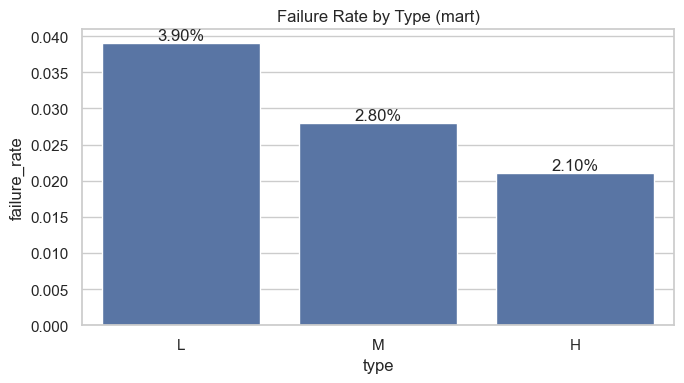

In [16]:
# ---------------------------------------------------------
# 12. 시각화: mart 기준 모니터링 그림 만들기
# ---------------------------------------------------------
plt.figure(figsize=(7, 4))
ax = sns.barplot(data=result1, x="type", y="failure_rate")
for i in ax.containers:
    ax.bar_label(i, fmt="{:.2%}")
plt.title("Failure Rate by Type (mart)")
plt.tight_layout()
plt.show()

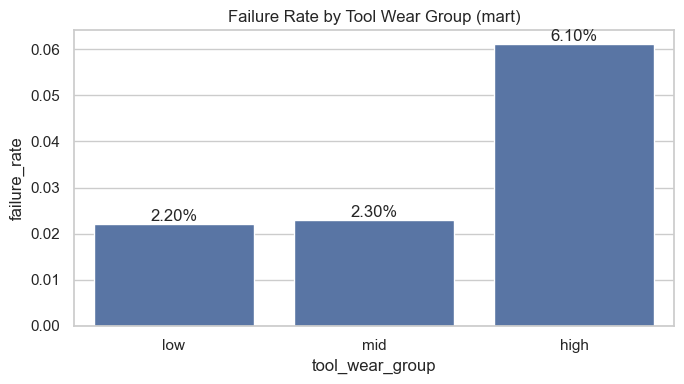

In [17]:
plt.figure(figsize=(7, 4))
ax = sns.barplot(data=result2, x="tool_wear_group", y="failure_rate")
for i in ax.containers:
    ax.bar_label(i, fmt="{:.2%}")
plt.title("Failure Rate by Tool Wear Group (mart)")
plt.tight_layout()
plt.show()

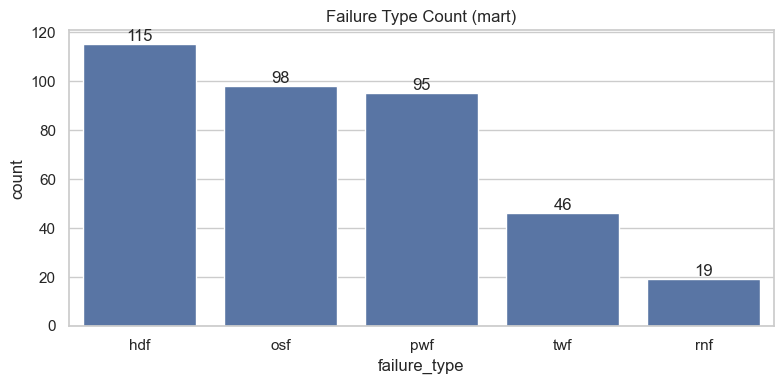

In [18]:
plt.figure(figsize=(8, 4))
ax = sns.barplot(data=result3, x="failure_type", y="count")
for i in ax.containers:
    ax.bar_label(i)
plt.title("Failure Type Count (mart)")
plt.tight_layout()
plt.show()

In [19]:
print("\n모니터링 시각화 해석")
print("- 운영 관점에서는 복잡한 원본보다, 요약된 mart 기준 그래프가 훨씬 보기 쉽습니다.")
print("- 이런 그래프는 대시보드나 주간 보고서의 기본 재료가 됩니다.")


모니터링 시각화 해석
- 운영 관점에서는 복잡한 원본보다, 요약된 mart 기준 그래프가 훨씬 보기 쉽습니다.
- 이런 그래프는 대시보드나 주간 보고서의 기본 재료가 됩니다.


In [20]:
# ---------------------------------------------------------
# 13. ETL 실행 로그 남기기
# ---------------------------------------------------------
etl_status = "SUCCESS" if quality_df["passed"].all() else "WARNING"

etl_log = pd.DataFrame([{
    "run_time": run_time,
    "source_file": str(source_file),
    "raw_file": str(raw_copy_path),
    "staging_file": str(staging_file),
    "row_count": len(df_staging),
    "column_count": len(df_staging.columns),
    "null_count_total": int(df_staging.isnull().sum().sum()),
    "type_match_rate": round(df_staging["type_match"].mean(), 4),
    "failure_rate": round(df_staging["machine_failure"].mean(), 4),
    "quality_pass_count": int(quality_df["passed"].sum()),
    "quality_fail_count": int((~quality_df["passed"]).sum()),
    "status": etl_status
}])

etl_log_path = log_dir / "etl_run_log.csv"

if etl_log_path.exists():
    old_log = pd.read_csv(etl_log_path)
    etl_log = pd.concat([old_log, etl_log], ignore_index=True)

etl_log.to_csv(etl_log_path, index=False, encoding="utf-8-sig")
etl_log.to_sql("etl_run_log", conn, if_exists="replace", index=False)

print("\nETL 실행 로그")
display(etl_log.tail())

print("\n실행 로그 해석")
print("- quality_pass_count: 통과한 품질 규칙 수")
print("- quality_fail_count: 실패한 품질 규칙 수")
print("- status: 전체 실행 상태")
print("- 실무에서는 이런 로그가 있어야 장애 원인을 추적하기 쉽습니다.")


ETL 실행 로그


,run_time,source_file,raw_file,staging_file,row_count,column_count,null_count_total,type_match_rate,failure_rate,quality_pass_count,quality_fail_count,status
0,20260325_125947,data/ai4i2020.csv,etl_project/raw/ai4i_raw_20260325_125947.csv,etl_project/staging/ai4i_staging_20260325_1259...,10000,22,0,1.000,0.034,6,0,SUCCESS



실행 로그 해석
- quality_pass_count: 통과한 품질 규칙 수
- quality_fail_count: 실패한 품질 규칙 수
- status: 전체 실행 상태
- 실무에서는 이런 로그가 있어야 장애 원인을 추적하기 쉽습니다.


In [21]:
# ---------------------------------------------------------
# 14. 품질 점검 결과 파일 저장
# ---------------------------------------------------------
quality_file = log_dir / f"quality_check_{run_time}.csv"
quality_df.to_csv(quality_file, index=False, encoding="utf-8-sig")

print("\n품질 점검 결과 저장:", quality_file)


품질 점검 결과 저장: etl_project/logs/quality_check_20260325_125947.csv


In [22]:
# ---------------------------------------------------------
# 15. mart 파일 저장
# ---------------------------------------------------------
mart_type_file = mart_dir / f"mart_type_summary_{run_time}.csv"
mart_wear_file = mart_dir / f"mart_wear_summary_{run_time}.csv"
mart_failure_file = mart_dir / f"mart_failure_summary_{run_time}.csv"

mart_type_summary.to_csv(mart_type_file, index=False, encoding="utf-8-sig")
mart_wear_summary.to_csv(mart_wear_file, index=False, encoding="utf-8-sig")
mart_failure_summary.to_csv(mart_failure_file, index=False, encoding="utf-8-sig")

print("\nmart 파일 저장 완료")
print(mart_type_file)
print(mart_wear_file)
print(mart_failure_file)


mart 파일 저장 완료
etl_project/mart/mart_type_summary_20260325_125947.csv
etl_project/mart/mart_wear_summary_20260325_125947.csv
etl_project/mart/mart_failure_summary_20260325_125947.csv


In [23]:
# ---------------------------------------------------------
# 16. 아주 간단한 모니터링 요약 카드 만들기
# ---------------------------------------------------------
monitoring_df = pd.DataFrame({
    "metric": [
        "total_rows",
        "failure_rate",
        "tool_wear_alert_rate",
        "quality_fail_count",
        "etl_status"
    ],
    "value": [
        len(df_staging),
        round(df_staging["machine_failure"].mean(), 4),
        round(df_staging["tool_wear_alert"].mean(), 4),
        int((~quality_df["passed"]).sum()),
        etl_status
    ]
})

print("\n모니터링 요약")
display(monitoring_df)

monitoring_file = log_dir / f"monitoring_summary_{run_time}.csv"
monitoring_df.to_csv(monitoring_file, index=False, encoding="utf-8-sig")

print("모니터링 요약 저장:", monitoring_file)


모니터링 요약


,metric,value
0,total_rows,10000
1,failure_rate,0.034
2,tool_wear_alert_rate,0.080
3,quality_fail_count,0
4,etl_status,SUCCESS


모니터링 요약 저장: etl_project/logs/monitoring_summary_20260325_125947.csv


In [24]:
# ---------------------------------------------------------
# 17. pytest 스타일 품질 테스트 예시 안내
# 실제 실행은 별도 파일(test_quality.py)에서 수행
# ---------------------------------------------------------
print("\npytest 스타일 테스트 예시")
print("- test_row_count: 데이터 행 수가 0보다 큰지 확인")
print("- test_valid_type: type 컬럼이 L/M/H만 가지는지 확인")
print("- test_machine_failure_binary: machine_failure가 0/1만 가지는지 확인")
print("- test_tool_wear_non_negative: tool_wear_min에 음수가 없는지 확인")

print("\n설명:")
print("- 이런 테스트는 데이터가 정상 범위 안에 있는지 자동으로 검사하는 역할을 합니다.")
print("- 사람이 매번 눈으로 확인하지 않아도, 파이프라인 실행 때마다 규칙을 검증할 수 있습니다.")
print("- 테스트가 실패하면, 분석이나 적재 전에 문제를 먼저 발견할 수 있습니다.")


pytest 스타일 테스트 예시
- test_row_count: 데이터 행 수가 0보다 큰지 확인
- test_valid_type: type 컬럼이 L/M/H만 가지는지 확인
- test_machine_failure_binary: machine_failure가 0/1만 가지는지 확인
- test_tool_wear_non_negative: tool_wear_min에 음수가 없는지 확인

설명:
- 이런 테스트는 데이터가 정상 범위 안에 있는지 자동으로 검사하는 역할을 합니다.
- 사람이 매번 눈으로 확인하지 않아도, 파이프라인 실행 때마다 규칙을 검증할 수 있습니다.
- 테스트가 실패하면, 분석이나 적재 전에 문제를 먼저 발견할 수 있습니다.


In [25]:
# ---------------------------------------------------------
# 18. DB 연결 종료
# ---------------------------------------------------------
conn.close()
print("\nDB 연결 종료")


DB 연결 종료


In [26]:
# ---------------------------------------------------------
# 19. 3일차 마무리 메시지
# ---------------------------------------------------------
print("\n" + "=" * 60)
print("3일차 정리")
print("=" * 60)
print("오늘은 데이터를")
print("1) ETL 흐름으로 처리하고")
print("2) 품질 규칙을 점검하고")
print("3) staging 데이터를 만들고")
print("4) SQLite에 적재하고")
print("5) mart 요약 테이블을 만들고")
print("6) SQL로 조회하고")
print("7) 실행 로그와 모니터링 파일까지 남겨봤습니다.")

print("\n핵심 메시지:")
print("- 데이터 파이프라인은 단순 저장이 아니라, 규칙과 기록이 있는 처리 체계입니다.")
print("- raw / staging / mart를 나누면 유지보수와 재활용이 쉬워집니다.")
print("- 품질관리와 모니터링은 나중에 붙이는 기능이 아니라 처음부터 설계해야 하는 핵심 요소입니다.")


3일차 정리
오늘은 데이터를
1) ETL 흐름으로 처리하고
2) 품질 규칙을 점검하고
3) staging 데이터를 만들고
4) SQLite에 적재하고
5) mart 요약 테이블을 만들고
6) SQL로 조회하고
7) 실행 로그와 모니터링 파일까지 남겨봤습니다.

핵심 메시지:
- 데이터 파이프라인은 단순 저장이 아니라, 규칙과 기록이 있는 처리 체계입니다.
- raw / staging / mart를 나누면 유지보수와 재활용이 쉬워집니다.
- 품질관리와 모니터링은 나중에 붙이는 기능이 아니라 처음부터 설계해야 하는 핵심 요소입니다.


In [27]:
# end